<a href="https://colab.research.google.com/github/Ameenota/HF-LLM/blob/main/Simplified_RAG_chatbot.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## **Small Business Chatbot**

RAG (Retrieval Augmented Generation) allows us to feed custom data into a language model. This has a large number of applications (customer support chatbot). Below we will build a RAG based chatbot for a family owned printing business. The business has around 200 of articles on their site. We will use this text to "augment" our chatbot and deploy a fulling working demo.

To run this you need to get your token from HuggingFace and create a secrect called HF_TOKEN with it.

Part 1 of this is Scraping Data which is covered [in another notebook](https://colab.research.google.com/drive/1rwjVCvog0BC97mVqQJ4q27T3kOnryOsX?usp=sharing). Below we will process the RAW data and prepare it for use in RAG

In [1]:
%%capture
!pip install faiss-cpu -q

from google.colab import userdata
HF_TOKEN=userdata.get('HF_TOKEN')

EMBEDDING_MODEL_NAME = "BAAI/bge-small-en-v1.5"
RAW_REPO_ID = "sagsan/orchid-website-data" ## contains just what we downloaded from the website
PROCESSED_REPO_ID = "sagsan/orchid-website-data-processed"


In [ ]:
%%capture
!crawl4ai-setup

In [ ]:
!crawl4ai-doctor

[INIT].... → Running Crawl4AI health check... 
[INIT].... → Crawl4AI 0.7.6 
[TEST].... ℹ Testing crawling capabilities... 
[EXPORT].. ℹ Exporting media (PDF/MHTML/screenshot) took 7.44s 
[FETCH]... ↓ https://crawl4ai.com                                               
| ✓ | ⏱: 11.98s 
[SCRAPE].. ◆ https://crawl4ai.com                                               
| ✓ | ⏱: 0.53s 
[COMPLETE] ● https://crawl4ai.com                                               
| ✓ | ⏱: 12.56s 
[COMPLETE] ● ✅ Crawling test passed! 


First we setup crawl4ai, most of this is just lifted off their site so I'm not going into it too much.

> Add blockquote



In [ ]:
from crawl4ai.deep_crawling import BFSDeepCrawlStrategy
from crawl4ai.content_filter_strategy import PruningContentFilter
from crawl4ai.async_configs import CrawlerRunConfig
from crawl4ai.markdown_generation_strategy import DefaultMarkdownGenerator

# A pruning filter is a heuristic filter used by crawl4AI to strip out nav bars, side bars, footers etc
prune_filter = PruningContentFilter(
        threshold=0.45,
        threshold_type="dynamic",
        min_word_threshold=5
    )
# we put the filter in the MD generator cause thats our outut format
md_generator = DefaultMarkdownGenerator(content_filter=prune_filter)

# Configuration for how each page is processed during the craw
crawler_config = CrawlerRunConfig(
        deep_crawl_strategy=BFSDeepCrawlStrategy(
            max_depth=10,
            include_external=False,
            max_pages=1000
        ),
        markdown_generator=md_generator,
        scraping_strategy=LXMLWebScrapingStrategy(),
        verbose=False
    )

The snippet below is the main website crawl loop. This can run for a while

In [ ]:
import asyncio
from crawl4ai import AsyncWebCrawler, CrawlResult
from typing import List, Dict, Any

async def crawl_page():
    async with AsyncWebCrawler() as crawler:
        result = await crawler.arun("https://orchiddigitals.com", config=crawler_config)
        return result

results = await crawl_page()

[INIT].... → Crawl4AI 0.7.6 

Our crawl is complete and below we process the results. Each result object comes with included metadata. First we strip all the content using .markdown.fit_markdown. Then we create a JSON object with page title, url and content. Its also a good idea to save the timestamp incase you decide to scrape frequently (we won't in this project as there are only ~200 relevant pages).

In [ ]:
from datetime import datetime, timezone

utc_now = datetime.now(timezone.utc).isoformat()
all_rag_documents: List[Dict[str, Any]] = []

for result in results:
  cleaned_markdown = result.markdown.fit_markdown
  source_url = result.url
  page_title = result.metadata.get("title", "No Title Found")

  if not cleaned_markdown or cleaned_markdown.strip() == "":
    # There are a lot of image only pages on the site that dont make any sense to save
    print(f"  [WARN] Skipping: No main content extracted for {source_url}")
    continue;

  # Create a RAG Document
  rag_doc = {
      "source": source_url,
      "title": page_title,
      "text": cleaned_markdown,
      "date_crawled": utc_now
  }
  all_rag_documents.append(rag_doc)
  print(f"  [OK] Processed '{page_title}' ({len(cleaned_markdown)} chars) - Total: {len(all_rag_documents)}")


  [OK] Processed 'Orchid Digitals - Pune's Premier Prints Provider - Order Your Prints Online' (3305 chars) - Total: 1
  [OK] Processed 'Orchid Digitals - Pune's Premier Prints Provider - Order Your Prints Online' (3305 chars) - Total: 2
  [OK] Processed 'In-store Branding Campaign. Prints, Installation & Reporting' (905 chars) - Total: 3
  [OK] Processed 'Our Blogs - Orchid Digitals' (343 chars) - Total: 4
  [OK] Processed 'Contact details, address, email ids and phone numbers of Orchid Digitals' (1057 chars) - Total: 5
  [OK] Processed 'Book & Manual Printing Service for Short-order Runs' (13684 chars) - Total: 6
  [OK] Processed 'Certificate printing on premium & textured papers' (14668 chars) - Total: 7
  [OK] Processed 'Dome stickers. Shape-cut as per your logo. Raised 3D effect.' (5559 chars) - Total: 8
  [OK] Processed 'About Us - Orchid Digitals' (7282 chars) - Total: 9
  [OK] Processed 'Sipper Printing service to create highly personalized gifts' (6235 chars) - Total: 10
  [OK

Lets inspect one of the items to make sure there is no obvious HTML or CSS remaining in there.

In [ ]:
all_rag_documents[2]

{'source': 'https://orchiddigitals.com/advertising-branding-retail-outlets',
 'title': 'In-store Branding Campaign. Prints, Installation & Reporting',
 'text': "* Pet shops across Pune are branded with product images and logos of the Royal Canin Company. See how we did this.\n* Case study of how our foam sheet and one way vision prints were installed at multiple retail outlets of the Godrej & Boyce company, in Pune city.\n* Case study of how backlit shop boards were deployed at virtually every pharmacy in the city to showcase J&J One Touch products\n* Case study of store branding carried out at beauty salons in Pune. Use of roll-up standees, flex and sunboard prints to highlight the Streax product range.\n* Case study of how our cut out foam sheet standee solution boosted the Diwali sales of a major white-goods & electronics company. Turn-key printing solution.\n## Didn't find what you were looking for?\nUnable to find information on a certain topic? Drop in a message here and we’ll ge

In [ ]:
## Upload to HF
df = pd.DataFrame(all_rag_documents)
dataset = Dataset.from_pandas(df)
dataset.push_to_hub(RAW_REPO_ID, private=True) # uncomment this if you actually want to push to hub

## Data processing
We have completed downloading all pages. Now we want to do a few things:
1) Examine the data and remove any obvious noise.
2) Create Embeddings and store everything in a HF dataset.

The reason we push everything into an HF dataset is that we don't need to crawl the website regularly. We can simply download preprocessed data which will be significantly faster.

Below I added a "length" within the dataset. I also did a histogram of length. Looking at the plot it is obvious that there are a large number of documents that are between 0->1000 length. Most of these are just noise and will not be useful in our search. We will remove them later.

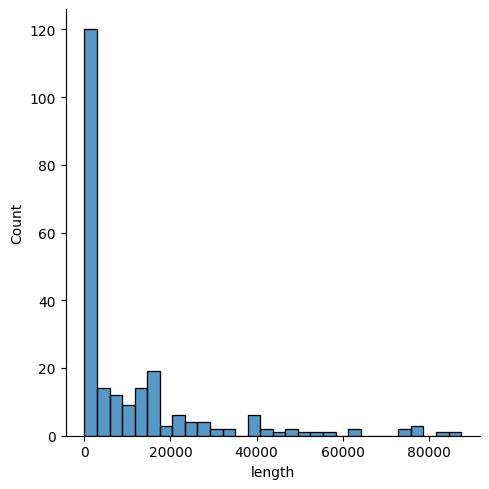

In [ ]:
from datasets import Dataset
from huggingface_hub import login, HfApi
import os
import pandas as pd
import seaborn as sns

def process_data(rag_docs):
  df = pd.DataFrame(all_rag_documents)

  #create length field
  df["length"] = df["text"].str.len()
  sns.displot(df["length"],bins=30)

  #create a combined text doc
  df["doc"] = (
      "TITLE: " + df['title'] +
      "\nSOURCE: " + df['source'] +
      "\nCONTENT: " + df['text']
  )
  return df


df = process_data(all_rag_documents)


Below we create the vector embeddings using "BAAI/bge-small-en-v1.5" as our model. This is a very small model (33 million params) purpose built for RAG.

In [3]:
from sentence_transformers import SentenceTransformer

EMBEDDING_MODEL = SentenceTransformer(EMBEDDING_MODEL_NAME)

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/52.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/743 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/366 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

In [1]:
df

NameError: name 'df' is not defined

In [ ]:

def create_embeddings_and_upload(df):
  dataset = Dataset.from_pandas(df)

  # Function to compute embeddings for a batch of texts
  def compute_embeddings(batch):
      return {'embeddings': EMBEDDING_MODEL.encode(batch["doc"], convert_to_numpy=True)}

  # Add the 'embeddings' column to the dataset
  dataset_with_embeddings = dataset.map(
      compute_embeddings,
      batched=True,
      desc="Creating Embeddings"
  )
  print("Embeddings created.")
  #dataset_with_embeddings.push_to_hub(REPO_ID, private=True) # uncomment this if you actually want to push to hub

create_embeddings_and_upload(df)


NameError: name 'df' is not defined

### Download the Data and Process for startup

Load the dataseet and add FAISS embeddings.

In [2]:
from datasets import load_dataset
def prepare_data_for_rag():
  dataset = load_dataset(REPO_ID ,split="train", token=HF_TOKEN)
  dataset.filter(lambda x: x["length"] > 1000)

  # Add the FAISS index to the dataset
  dataset.add_faiss_index(column='embeddings')
  print("FAISS index built successfully.")
  return dataset

DATASET = prepare_data_for_rag()
DATASET

NameError: name 'REPO_ID' is not defined

In [ ]:
len(DATASET[33]['embeddings'])

384

In [ ]:
def chunk_text(text, chunk_size=1000, overlap=200):
    """
    Break `text` into chunks of ~chunk_size characters,
    with `overlap` characters of context between chunks.
    """
    chunks = []
    start = 0
    text_len = len(text)

    while start < text_len:
        end = start + chunk_size
        chunk = text[start:end]
        chunks.append(chunk)
        # move start forward but keep some overlap
        start = end - overlap

        if start < 0:
            start = 0

    return chunks

df = DATASET.to_pandas()
df = df.reset_index().rename(columns={"index": "doc_id"})

df["chunks"] = df["doc"].apply(lambda t: chunk_text(t))
chunked_df = (
    df[["doc_id", "chunks"]]
    .explode("chunks", ignore_index=True)
    .rename(columns={"chunks": "chunk_text"})
)

3377

## Inference
Below we complete the 3 stages required to actually answer questions.

### Step-1: Modify incoming question
Assume a user asks a question such as "What is your address". A vector search will not match appropriate documents to this search directly. What we want to do is modify the question before its sent to our vector search. To do this we create a simple prompt as shown below. This will modify the incoming question to something that will work better in our search context. By doing this we modify our users incoming query to be more detailed "Orchid Enterprises corporate address"

In [ ]:
from huggingface_hub import InferenceClient
MODEL_NAME = "openai/gpt-oss-120b"

query_system_prompt = (
    "**Role:** You are an expert Query Transformer for a specialized search engine.\n"
    "**Context:** All documents in the search index are exclusively about 'Orchid Enterprises'.\n"
    "**Task:** Your goal is to rephrase the user's input question into the most clear, non-ambiguous, and optimized search query for this specialized context.\n"
    "**Constraint:** Only output the new, rephrased search query. DO NOT include any other text, explanation, or conversational filler."
)
CLIENT = InferenceClient()

def query_transformer(question):
  completion = CLIENT.chat.completions.create(
      model=MODEL_NAME,
      messages=[
          {
            "role": "system",
            "content": query_system_prompt
          },
          {
              "role": "user",
              "content": question
          }
      ],
  )
  return completion.choices[0].message.content



### Step-2: Vector Embeddings Search
Below we implement the actual vector embeddings search. Note the call to query_transformer modifies the question before it is actually used for search.  

In [ ]:

def get_relevant_documents(question):
    question = query_transformer(question)
    print(f"Transformed question: {question}")
    # Embed the query
    query_embedding = EMBEDDING_MODEL.encode(question)

    # Search the FAISS index for the top k nearest neighbors (documents)
    scores, retrieved_rows = DATASET.get_nearest_examples(
        'embeddings', query_embedding, k=4
    )

    # Compile the context from the retrieved documents
    retrieved_context = ""
    for text,score in zip(retrieved_rows["text"], scores):
        #doc_text = dataset_with_embeddings[idx][TEXT_COLUMN]
        retrieved_context += f"Document Score: {score:.4f}\nRETRIEVED_TEXT: {text}\n---\n"

    print(f"Retrieved {len(retrieved_rows)} documents for context.")

    return retrieved_context

response = get_relevant_documents("what is your address")


Transformed question: Orchid Enterprises corporate address
Retrieved 7 documents for context.


### Step-3: Create a chat RAG Agent
This is the main input step for our agent. We take the question, execute vector search, pass the received documents along with the question and let our model answer the question

In [ ]:
import os
import json

SYSTEM_INSTRUCTION = (
    "You are an accurate, helpful RAG assistant for a printshop called Orchid Enterprises whose CEO's name is Mitesh Sanghani"
    "If the answer is not contained within the context, state 'I do not know the answer.' "
    "Maintain the conversation history in your responses."
)

client = InferenceClient()

def get_rag_completion(conversation_history: list, new_user_question: str, rag_context: str) -> list:
    # --- 1. Construct the new user message with RAG context ---
    user_content = (
        f"Context for this turn: {rag_context}\n"
        f"Question: {new_user_question}"
    )

    # --- 2. Append the new user message to the history ---
    conversation_history.append({
        "role": "user",
        "content": user_content
    })
    print(json.dumps(conversation_history, indent=2))

    # --- 3. Call the API with the ENTIRE conversation history ---
    completion = client.chat.completions.create(
        model=MODEL_NAME,
        messages=conversation_history, # Sending the full list of messages
    )
    print("GOT AN ANSWER!")

    # --- 4. Append the model's response to the history ---
    assistant_response = completion.choices[0].message
    conversation_history.append({
        "role": "assistant",
        "content": assistant_response.content
    })

    return conversation_history



conversation_history = [
    {
        "role": "system",
        "content": SYSTEM_INSTRUCTION
    }
]



question_t1 = "what is a standee? what do your charge for it?"
rag_context_t1 = get_relevant_documents(question_t1)
conversation_history = get_rag_completion(conversation_history, question_t1, rag_context_t1)


print("\n--- Full Conversation History (List of Messages) ---")
print(json.dumps(conversation_history, indent=2))


--- Starting New Conversation with Model: openai/gpt-oss-120b ---
Transformed question: Orchid Enterprises standee definition and pricing information
Retrieved 7 documents for context.
[
  {
    "role": "system",
    "content": "You are an accurate, helpful RAG assistant for a printshop called Orchid Enterprises whose CEO's name is Mitesh SanghaniIf the answer is not contained within the context, state 'I do not know the answer.' Maintain the conversation history in your responses."
  },
  {
    "role": "user",
    "content": "Context for this turn: Document Score: 0.5510\nRETRIEVED_TEXT: # Terms and Conditions for Orchid Digitals\nThese Website Standard Terms and Conditions written on this webpage shall manage your use of our website, Orchid Digitals accessible at \nThese Terms will be applied fully and affect your use of this Website. By using this Website, you agreed to accept all terms and conditions written in here. You must not use this Website if you disagree with any of these W

In [ ]:
print(conversation_history[2]['content'])

**What is a standee?**  

A standee is a printed display panel that is cut or mounted in a self‑supporting shape and used for advertising, point‑of‑sale promotion, exhibitions, events, selfie‑booths, etc.  
Orchid Enterprises offers several kinds of standees:

| Type | Typical size(s) | Description |
|------|----------------|-------------|
| **Roll‑up (collapsible) standees** | 6 ft × 3 ft (standard) – also 5 × 2 ft, 6 × 4 ft, 6 × 6 ft, 8 × 8 ft | Light‑weight banner that rolls into a spring‑loaded cylinder, comes in a travel bag and can be set up in ~2 minutes. |
| **Luxury roll‑up standees** | Same dimensions as roll‑up but with a heavier, wider base for extra stability (ideal for windy/open‑ground locations). |
| **Shape‑cut (sunboard) standees** | Custom shapes; common sizes 3 ft × 2 ft, 3 ft × 4 ft, 3 ft × 6 ft, 4 ft × 6 ft, etc. | Printed on 5 mm thick sunboard and CNC‑router cut into the exact contour of a logo, cartoon, product, etc. |
| **Table‑top (A4/A3) standees** | A4‑size

In [ ]:

# # Extract and print the last response (the latest assistant message)
# response_t1 = conversation_history[-1]['content']
# print(f"\n[Turn 1] User Question: {question_t1}")
# print(f"[Turn 1] Assistant Response: {response_t1}")


# # --- Turn 2: Follow-up question, showing the history is retained ---
# # The model will use the history from Turn 1 to understand what "all three branches" refers to.
# rag_context_t2 = """
# The three branches are the executive, the legislature, and the judiciary.
# The President of India is the head of the executive branch.
# """
# question_t2 = "Which city hosts the seat of all three branches?"

# conversation_history = get_rag_completion(conversation_history, question_t2, rag_context_t2)

# Extract and print the latest response
# response_t2 = conversation_history[-1]['content']
# print(f"\n[Turn 2] User Question: {question_t2}")
# print(f"[Turn 2] Assistant Response: {response_t2}")
